# Input

In [47]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats
# from ciim.src.tf_activity.plots import  plot_net_nx, plot_trend_tfs

from ciim.src.clock.helper import clock_save_dir, predict_age, prepare_input

# - settings
feature_type = 'tf_activity' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' #'tabpfn'
tune_model = False
version = 'v1.0'
temp_dir = '/vol/projects/jnourisa/output/temp/'

cell_types = ['CD4T','CD8T', 'MONO', 'B', 'NK'] # ['CD4T','CD8T', 'MONO', 'B', 'NK']
n_cell_types = len(cell_types)
# datasets_training = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese']

#TODO: use scvi extending embding

# scVI experiment

In [12]:
import scvi

# adata = ad.read_h5ad('../output/temp/CD8T_bulk_tf_activity_NN_adata.h5ad')
# adata.X = adata.X+np.min(adata.X)

adata = ad.read_h5ad('../../task_grn_inference/resources/grn_benchmark/inference_data/op_rna.h5ad')

In [17]:
import torch
from torch import nn
from scvi.modules import VAEModule
from scvi.nn import FCLayers
class SCVIAge(VAEModule):
    def __init__(self, n_input, n_batch, **kwargs):
        super().__init__(
            n_input=n_input,
            n_batch=n_batch,
            n_labels=None,
            **kwargs
        )

        self.age_predictor = FCLayers(
            n_in=self.latent_dim,
            n_out=1,  # regression; for classification, use n_out=n_classes
            n_hidden=64,
            n_layers=2,
            dropout_rate=0.1
        )

        self.age_loss_fn = nn.MSELoss()

    def forward(self, x, batch_index, age=None):
        inference_outputs = self.inference(x, batch_index)
        generative_outputs = self.generative(
            z=inference_outputs["z"],
            library=inference_outputs["library"],
            batch_index=batch_index,
        )

        # Predict age from z
        age_pred = self.age_predictor(inference_outputs["z"])
        inference_outputs["age_pred"] = age_pred
        inference_outputs["age_true"] = age

        return inference_outputs, generative_outputs

    def loss(self, tensors, inference_outputs, generative_outputs):
        loss_dict = super().loss(tensors, inference_outputs, generative_outputs)

        if inference_outputs["age_true"] is not None:
            age = inference_outputs["age_true"].float().unsqueeze(1)
            age_pred = inference_outputs["age_pred"]
            age_loss = self.age_loss_fn(age_pred, age)
            loss_dict["age_loss"] = age_loss
            loss_dict["loss"] += age_loss

        return loss_dict

ModuleNotFoundError: No module named 'scvi.modules'

In [15]:
# Register AnnData
scvi.model.SCVI.setup_anndata(adata, batch_key="donor_id")

# Create and train model
model = scvi.model.SCVI(adata)
model.to_device("cuda")
model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/313 [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
latent = model.get_latents()

# Previous aging model

In [2]:
if False:
    dataset = 'SLE_European' #'SLE_European' #'CXCL9' 
    data_file = f"/vol/projects/jnourisa/datasets/{dataset}_metacell.h5ad"
    output_file = f'../output/clock/{dataset}.csv'
    r_script_path = "../src/clock/AgeingClock_application_h5ad.R"
    if dataset == 'SLE_European':
        condition = 'disease'
    elif dataset == 'CXCL9':
        condition = 'treatment'
    else:
        condition = 'nada'


    result = subprocess.run(
        ["Rscript", r_script_path, data_file, output_file, condition],
        capture_output=True, text=True
    )
    print("STDOUT:\n", result.stdout)
    print("STDERR:\n", result.stderr)
    if result.returncode != 0:
        print("R script failed.")
    else:
        print("R script executed successfully.")
    
    df_all = pd.read_csv(output_file, sep="\t")
    df_all_bulk = df_all.groupby(['donor_id', 'cell_type', 'condition', 'age', 'sex'])['predicted_age'].median().reset_index()
    df_all_bulk.head()

# Calculate TF activity with consensus GRNs

In [16]:
from ciim.src.clock.helper import prepare_input, predict_age

os.makedirs(f'{save_dir}/tf_activity_smoothed', exist_ok=True)
for dataset in datasets_all+datasets_disease+datasets_drug_perturbation:
    for cell_type in cell_types:
        adata = prepare_input(dataset, cell_type, feature_type='tf_activity', data_type='bulk')
        adata.write(f'{save_dir}/tf_activity_smoothed/{dataset}_{cell_type}_bulk.h5ad')

data1 (981, 157)
data1 (981, 260)
data1 (772, 400)
data1 (978, 231)
data1 (981, 102)
data7_allTPs_jalil (313, 157)
data7_allTPs_jalil (313, 260)
data7_allTPs_jalil (313, 400)
data7_allTPs_jalil (312, 231)
data7_allTPs_jalil (313, 102)
data12 (61, 157)
data12 (61, 260)
data12 (61, 400)
data12 (60, 231)
data12 (61, 102)
SLE_European (150, 157)
SLE_European (150, 260)
SLE_European (150, 400)
SLE_European (148, 231)
SLE_European (150, 102)
data13_Korean (165, 157)
data13_Korean (165, 260)
data13_Korean (165, 400)
data13_Korean (165, 231)
data13_Korean (164, 102)
data13_Japanese (148, 157)
data13_Japanese (147, 260)
data13_Japanese (147, 400)
data13_Japanese (145, 231)
data13_Japanese (147, 102)
SLE_European (150, 157)
SLE_European (150, 260)
SLE_European (150, 400)
SLE_European (148, 231)
SLE_European (150, 102)
Covid_50MHH (42, 157)
Covid_50MHH (42, 260)
Covid_50MHH (42, 400)
Covid_50MHH (42, 231)
Covid_50MHH (42, 102)
CXCL9 (77, 157)
CXCL9 (77, 260)
CXCL9 (77, 400)
CXCL9 (77, 231)
CXCL9 

# Train

In [52]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *aging_clock_train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,

    ]
    if tune_model:
        cmd += ["--tune_model"]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD4T CD8T MONO B NK --datasets_training data1 data7_allTPs_jalil SLE_European data13_Japanese --feature_type tf_activity --data_type bulk --reg_type ridge --version v1.0 --temp_dir /vol/projects/jnourisa/output/temp/
{'cell_types': ['CD4T', 'CD8T', 'MONO', 'B', 'NK'], 'datasets_training': ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese'], 'feature_type': 'tf_activity', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': False, 'version': 'v1.0', 'temp_dir': '/vol/projects/jnourisa/output/temp/'}
building model for cell type: CD4T


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


building model for cell type: CD8T


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


building model for cell type: MONO


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


building model for cell type: B


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


building model for cell type: NK


/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


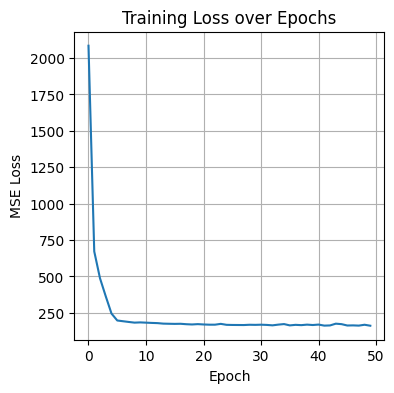

In [22]:
loss = np.load('tmp/loss.npy')
plt.plot(loss)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

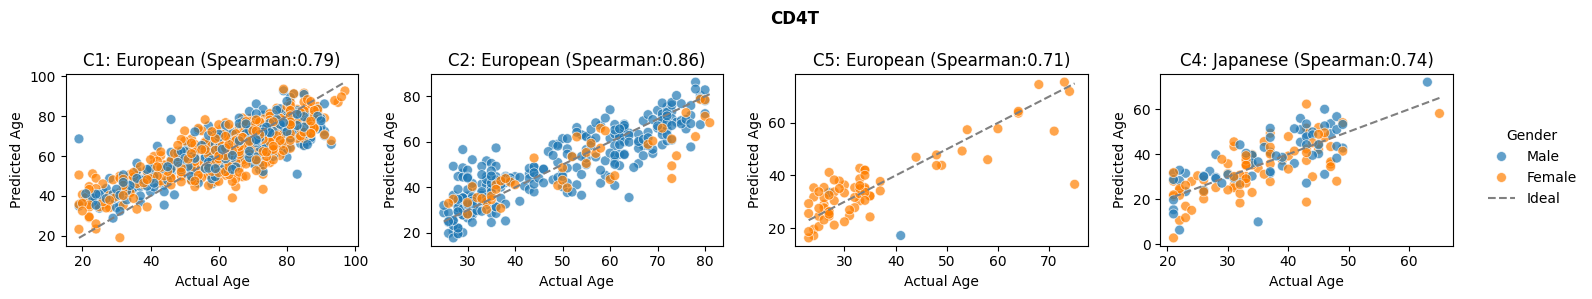

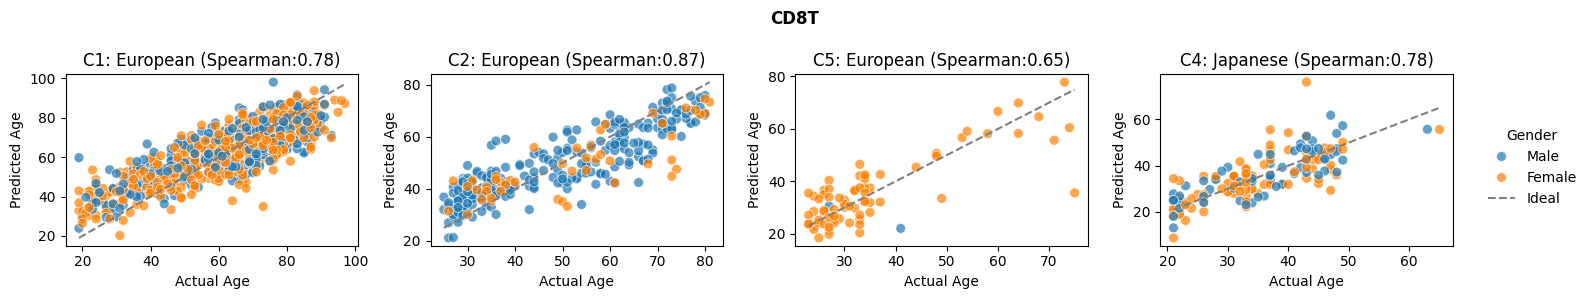

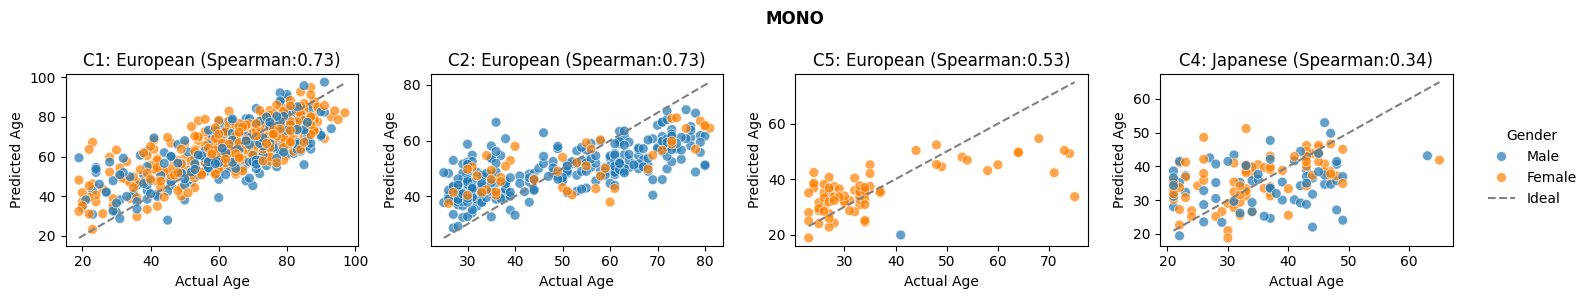

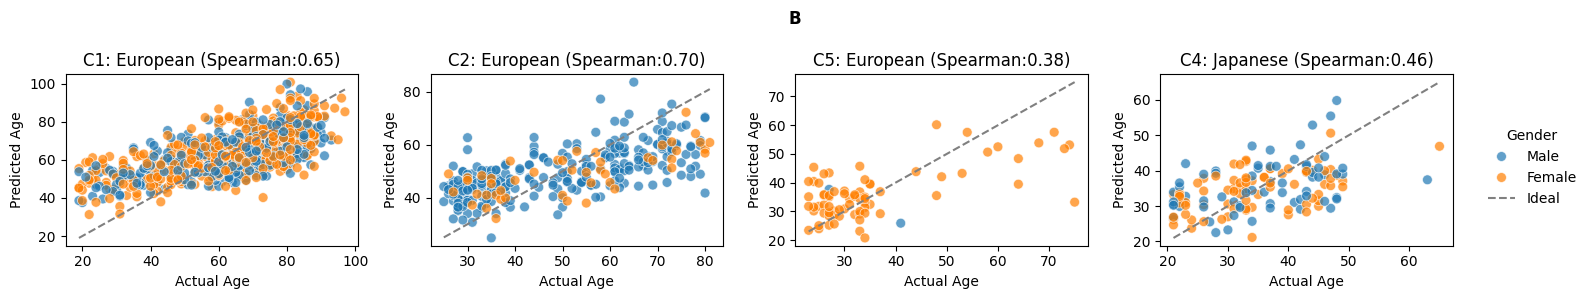

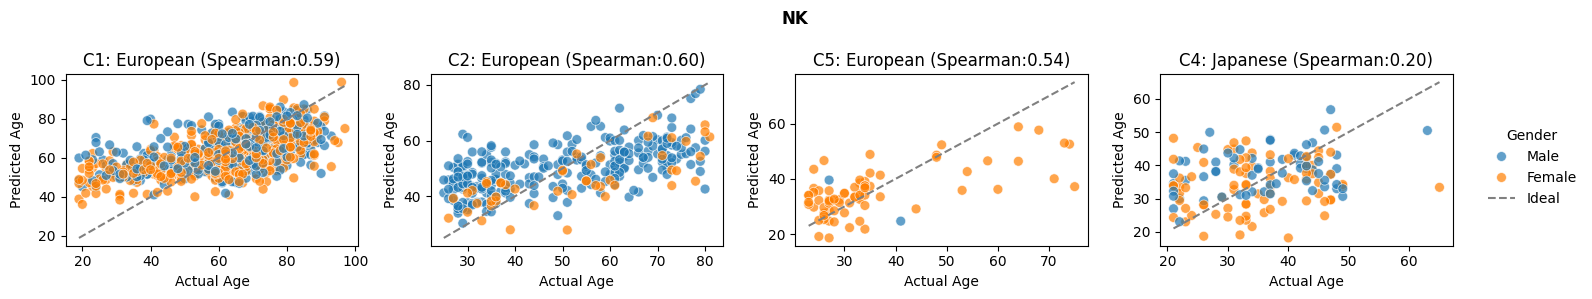

In [53]:
from ciim.src.clock.helper import evaluate_groupwise_median

for cell_type in cell_types:
    adata_all = ad.read_h5ad(f"{temp_dir}{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
    obs = adata_all.obs.copy()
    obs['sex'] = obs['sex'].astype(str)
    obs['donor_id'] = obs['donor_id'].astype(str)
    obs['age'] = obs['age'].astype(float)
    obs['predicted_age'] = obs['predicted_age'].astype(float)

    datasets = obs['dataset'].unique()
    fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 3))
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

        obs_d = obs_d.groupby(['donor_id', 'age', 'sex'])['predicted_age'].median().reset_index()

        
        sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
        min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
        ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

        ax.set_xlabel("Actual Age")
        ax.set_ylabel("Predicted Age")

        spearman = evaluate_groupwise_median(obs_d)['Spearman']
        ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")

        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .2), frameon=False, title='Gender')

    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()

# Feature importance

In [54]:
from ciim.src.clock.helper import stability_selection_shap, retrieve_function
def select_features(cell_type, top_q=None, top_features=50):
    
    return gene_names
shap_rr_store = []
for cell_type in cell_types: # feature selction for all cell types
    # - get the data
    adata = ad.read_h5ad(f"{temp_dir}{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
    X = adata.X.copy()
    y = adata.obs['age'].values
    # - retrieve the model and feature space 
    model, gene_names = retrieve_function(reg_type, cell_type, data_type, feature_type, version)
    assert (gene_names==adata.var_names).all(), "Gene names do not match!"
    # - feature selection
    rr = stability_selection_shap(gene_names, model, X.copy(), y, top_q=None, top_features=50)
    rr['cell_type'] = cell_type
    shap_rr_store.append(rr)
shap_rr = pd.concat(shap_rr_store)

In [55]:
shap_rr[(shap_rr['cell_type'] == 'CD8T') & (shap_rr['feature'] == 'SOX4')]
# shap_rr[(shap_rr['cell_type'] == cell_type)]

,importance,feature,cell_type
7,1.208244,SOX4,CD8T


Only 5 datasets are available in the stats.
True


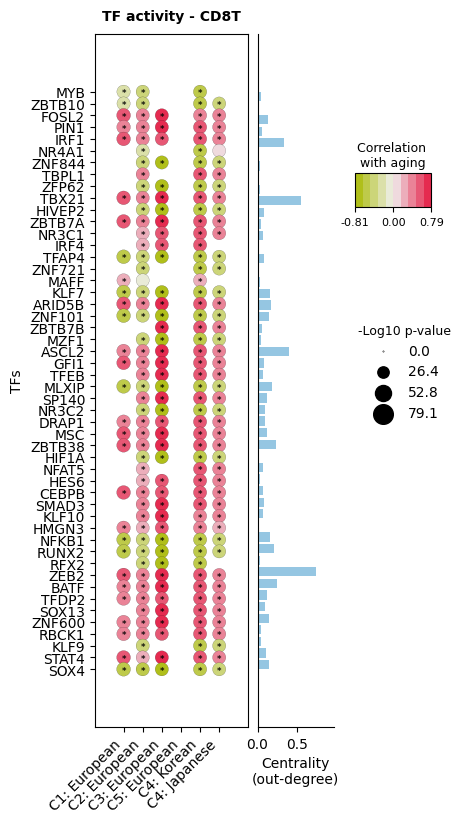

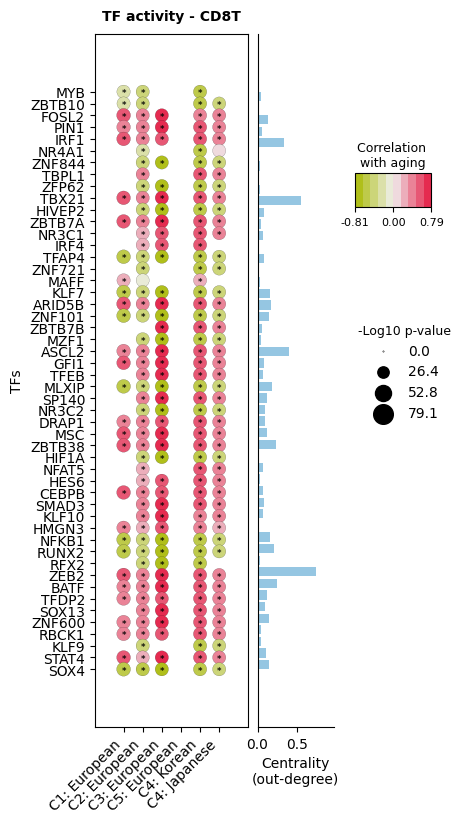

In [46]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

cell_type = 'CD8T'
top_tfs = shap_rr[shap_rr['cell_type'] == cell_type]['feature'].values
plot_features_vs_datasets(cell_type=cell_type, type=data_type, datasets=datasets_all, features=top_tfs, feature_type='tf_activity', sizes=(90, 100), width=4, margins={'x': 0.3, 'y': 0.1})


# Evaluation

In [18]:
force_write = True

In [26]:

evaluate_datasets = datasets_all + datasets_disease + datasets_drug_perturbation # 'data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean' , 'data13_Japanese', 
# evaluate_datasets = ['data13_Korean', 'data7_allTPs_jalil', 'SLE_European', 'Covid_50MHH', 'CXCL9']
prediction_file = f'{clock_save_dir}/prediction/{feature_type}_{data_type}_{reg_type}.csv'
if (force_write) or not os.path.exists(prediction_file):
    os.makedirs(f'{clock_save_dir}/prediction', exist_ok=True)
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/tf_activity_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs.rename(columns={'disease': 'condition', 'treatment':'condition', 'Max_WHO_Group':'condition'}, inplace=True)
            if 'condition' not in adata.obs.columns:
                adata.obs['condition'] = 'healthy'
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type)
                obs = adata_c.obs[['age', 'predicted_age', 'sex', 'donor_id']].copy() 
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    obs.to_csv(prediction_file, index=False)
else:
    obs = pd.read_csv(prediction_file)
obs.head()

{'Spearman': 0.7736878516157251, 'R2': 0.6507553703475415}
{'Spearman': 0.8523673691627132, 'R2': 0.7321054125868618}
{'Spearman': 0.8792169906458666, 'R2': 0.3240787795223521}
{'Spearman': 0.7972562146166806, 'R2': 0.566848666059687}
{'Spearman': 0.7164887043204975, 'R2': 0.6816071542654939}
{'Spearman': 0.766197619061871, 'R2': 0.4146138264290117}
{'Spearman': 0.7075477276809833, 'R2': 0.18182529999957953}
{'Spearman': 0.7972562146166806, 'R2': 0.566848666059687}
{'Spearman': 0.7164887043204975, 'R2': 0.6816071542654939}
{'Spearman': 0.7279596598287921, 'R2': -0.23708323328456027}
{'Spearman': 0.32899964497528417, 'R2': -0.5684865763490008}
{'Spearman': 0.30631873731649006, 'R2': -113.47367197123151}
{'Spearman': 0.30631873731649006, 'R2': -93.47046592169009}
{'Spearman': 0.198206241793023, 'R2': -184.2111887502765}
{'Spearman': 0.36037498507822363, 'R2': -149.41473326159672}
{'Spearman': 0.16216874328520064, 'R2': -124.16578649011662}
{'Spearman': 0.16216874328520064, 'R2': -134.776

,age,predicted_age,sex,donor_id,dataset,cell_type,condition
sample,,,,,,,
1000,80,78.310587,Female,Data1_1020_1021,data1,CD4T,healthy
1001,75,78.887708,Female,Data1_1021_1022,data1,CD4T,healthy
1002,68,66.598769,Female,Data1_1022_1023,data1,CD4T,healthy
1003,60,63.952774,Female,Data1_1023_1024,data1,CD4T,healthy
1004,70,75.188726,Female,Data1_1024_1025,data1,CD4T,healthy


## Performance on train data

### Line plot

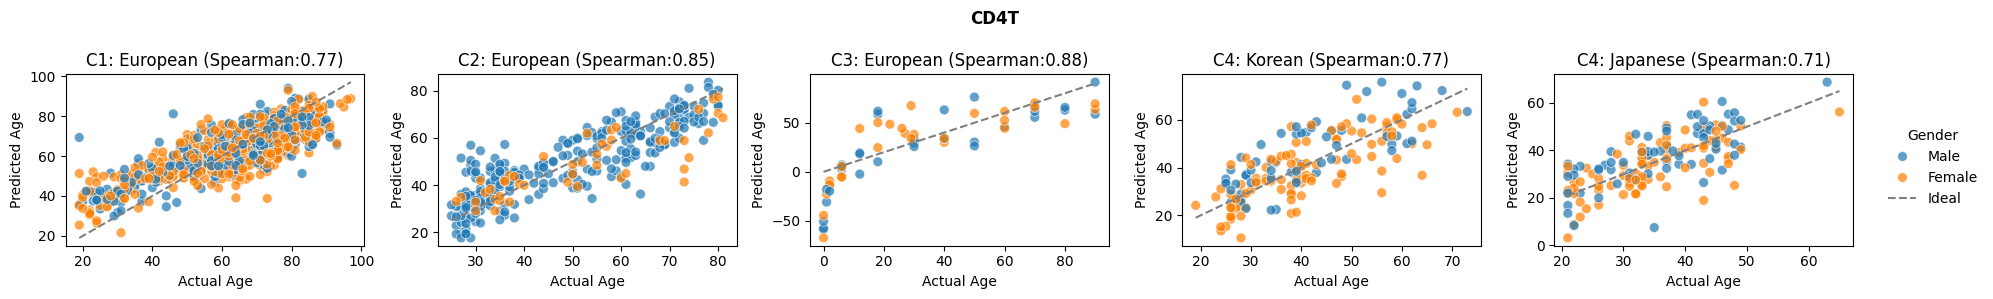

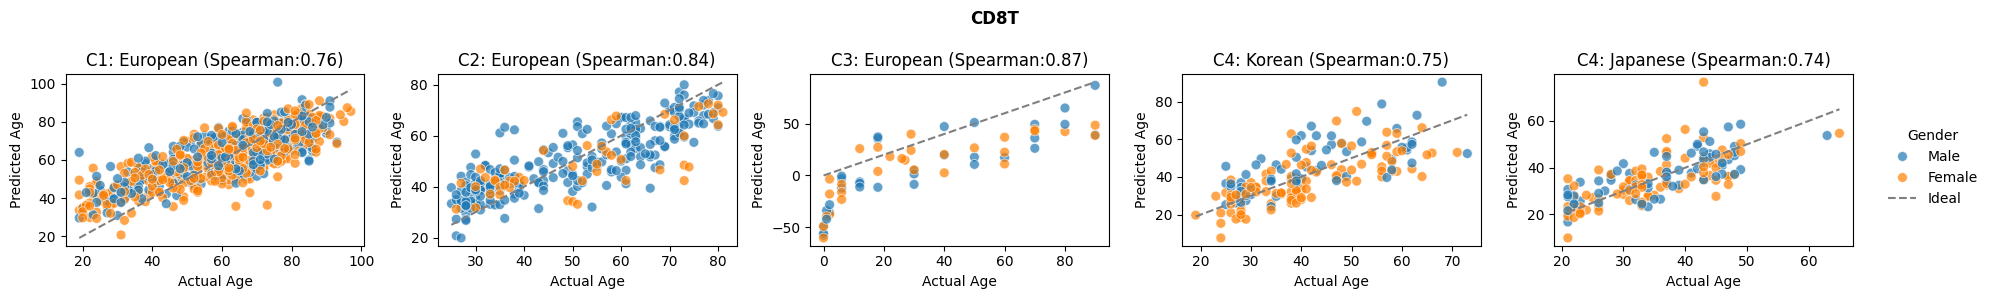

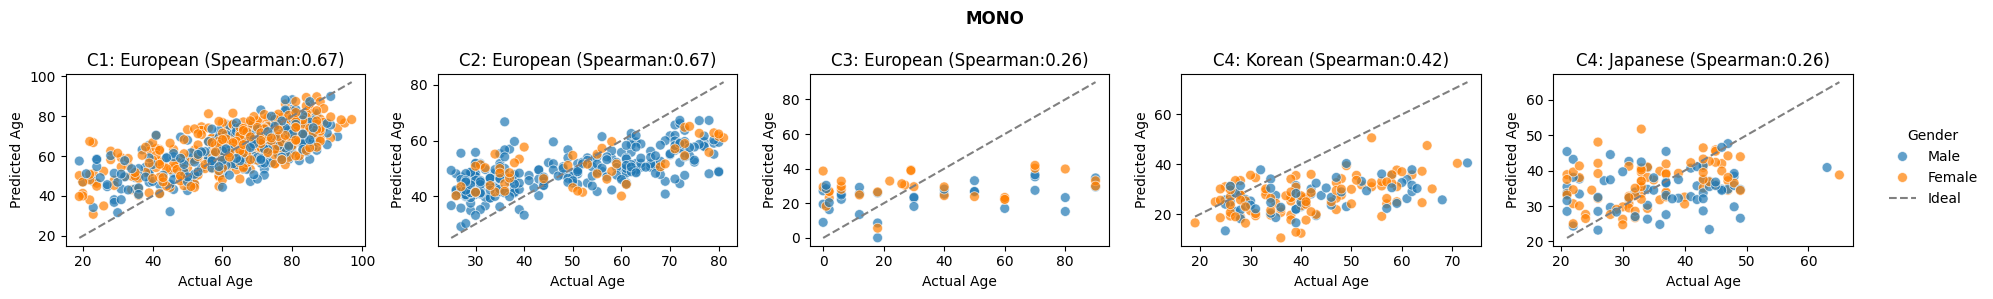

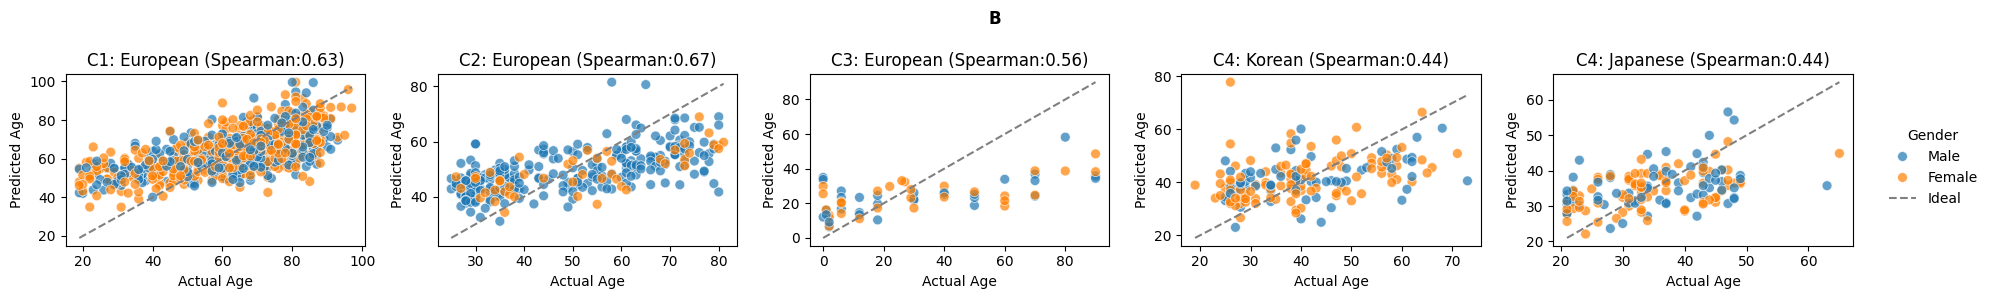

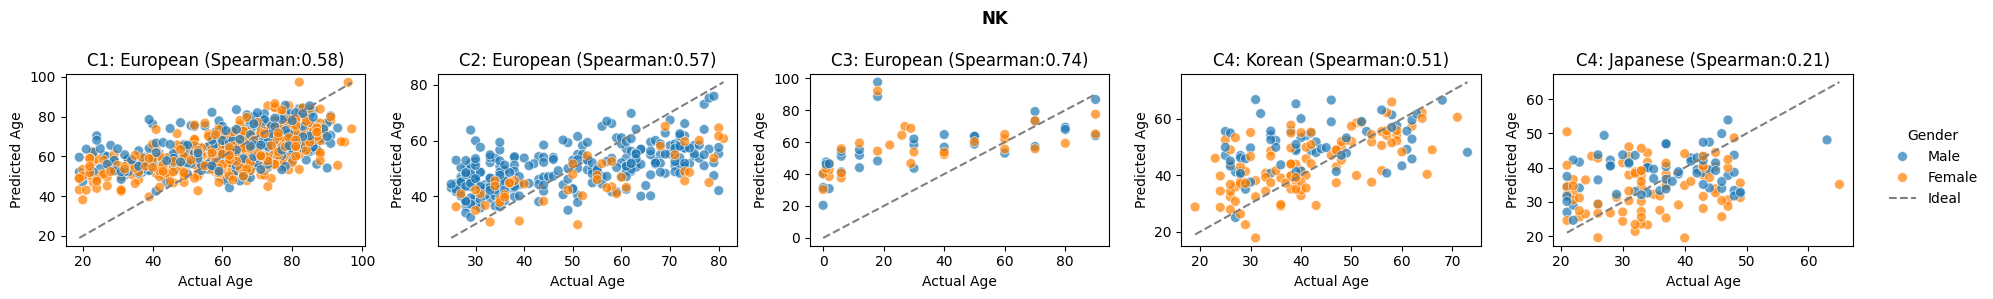

In [27]:
from ciim.src.clock.helper import evaluate_groupwise_median

obs['sex'] = obs['sex'].astype('str')

datasets_healthy = [d for d in  datasets_all if d in obs[(obs['condition'] == 'healthy')]['dataset'].unique()]

if True:
    for cell_type in cell_types:
        fig, axes = plt.subplots(1, len(datasets_healthy), figsize=(4*len(datasets_healthy), 3))
        i = 0
        for dataset in datasets_healthy:
            ax = axes[i] if len(datasets_healthy) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = obs_d.groupby(['donor_id', 'age', 'sex'])['predicted_age'].median().reset_index()


            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")
            spearman = evaluate_groupwise_median(obs_d)['Spearman']
            ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")

            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')
        
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

### Summary plot

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from ciim.src.clock.helper import evaluate_groupwise_median


datasets_healthy = ['data1', 'data7_allTPs_jalil', 'SLE_European' ,'data13_Japanese', 'data12', 'data13_Korean'] 
datasets_healthy = [d for d in datasets_healthy if d in obs['dataset'].unique()]

scores = []
for cell_type in cell_types:
    for dataset in datasets_healthy:
        df = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
        obs_d = df.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()

        rr = evaluate_groupwise_median(obs_d)
        spearman = rr['Spearman']
        r2 =  rr['R2']

        scores.append({
            'cell_type': cell_type,
            'dataset': dataset,
            'Spearman': spearman,
            'R2': r2
        })
scores_df = pd.DataFrame(scores)
scores_long = scores_df.melt(id_vars=['cell_type', 'dataset'], 
                              value_vars=['Spearman', 'R2'], 
                              var_name='metric', value_name='score')
scores_long['dataset'] = scores_long['dataset'].apply(lambda name: surrogate_names.get(name, name))
scores_long.head()

,cell_type,dataset,metric,score
0,CD4T,C1: European,Spearman,0.773688
1,CD4T,C2: European,Spearman,0.852367
2,CD4T,C5: European,Spearman,0.814864
3,CD4T,C4: Japanese,Spearman,0.707548
4,CD4T,C3: European,Spearman,0.879217


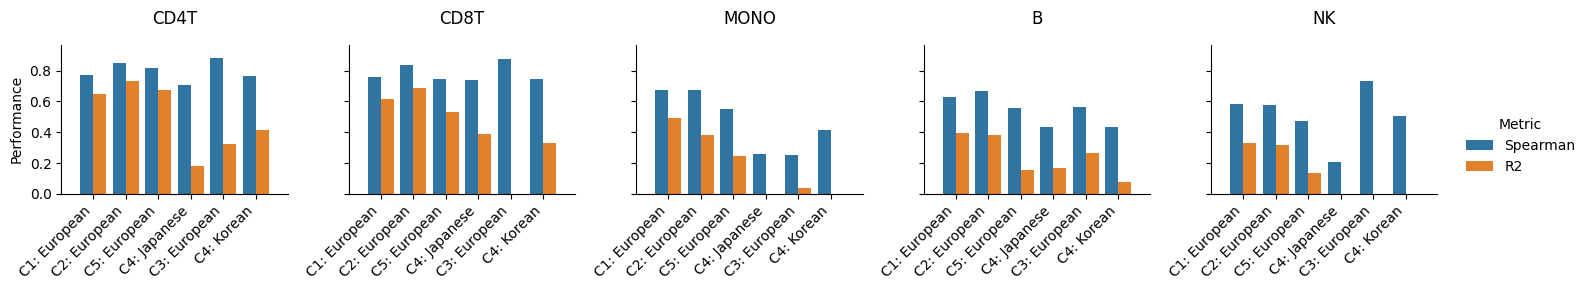

In [29]:
def multipanel_plot():
    fig, axes = plt.subplots(1, len(cell_types), figsize=(3*len(cell_types)+1, 3), sharey=True)
    for i, (cell_type) in enumerate(cell_types):
        ax = axes[i] if len(cell_types) > 1 else axes
        df_s = scores_long[scores_long['cell_type'] == cell_type]
        df_s['score'] = df_s['score'].clip(lower=0, upper=1) # clip the scores

        sns.barplot(
                ax=ax,
                data=df_s,
                x='dataset', y='score', hue='metric')
        ax.set_title(f"{cell_type}", pad=15)
        ax.set_ylabel("Performance")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(y=.1, x=.1)
    ax.legend(loc=(1.1, .1), title='Metric', frameon=False, fontsize=10)
    
    plt.tight_layout()
    
multipanel_plot()

#### ridge

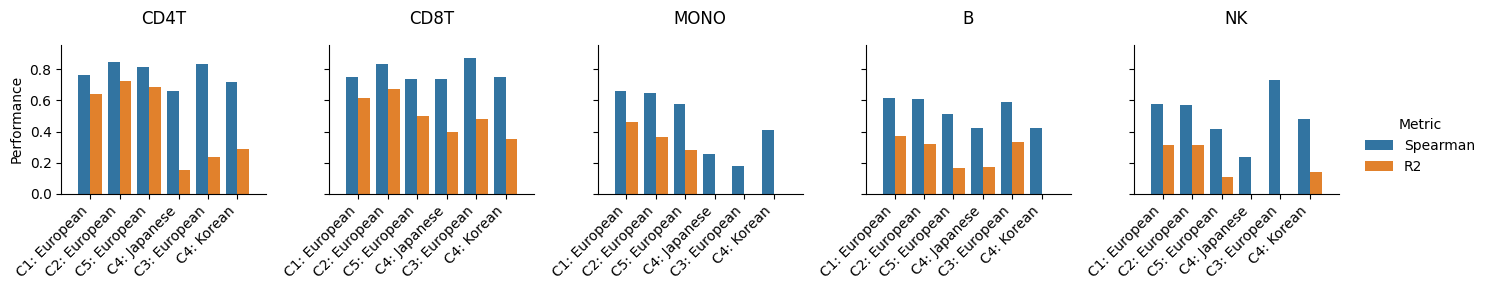

## Performance on disease

In [30]:
disease_dataset = 'SLE_European'
if disease_dataset == 'Covid_50MHH':
    disease_name = 'COVID-19'
    ctr = 'mild' #'normal'
    cond = 'severe'#'systemic lupus erythematosus'
elif disease_dataset == 'SLE_European':
    disease_name = 'SLE' 
    ctr = 'normal' #'normal'
    cond = 'systemic lupus erythematosus'#'systemic lupus erythematosus'

obs_disease = obs[obs['dataset'] == disease_dataset].copy()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import numpy as np

obs_disease['age'] = obs_disease['age'].astype(float)
obs_disease['donor_id'] = obs_disease['donor_id'].astype(str)
obs_disease['cell_type'] = obs_disease['cell_type'].astype(str)
obs_disease['condition'] = obs_disease['condition'].astype(str)
conds = obs_disease['condition'].unique()

In [31]:
df_pivot = obs_disease.pivot_table(index=['age', 'cell_type'], columns='condition', values='predicted_age')
df_pivot = df_pivot.reset_index()
df_pivot['diff'] = df_pivot[cond] - df_pivot[ctr]
df_pivot

condition,age,cell_type,normal,systemic lupus erythematosus,diff
0,22.0,B,NaN,39.545739,NaN
1,22.0,CD4T,NaN,29.392068,NaN
2,22.0,CD8T,NaN,21.474649,NaN
3,22.0,MONO,NaN,52.357321,NaN
4,22.0,NK,NaN,39.299194,NaN
...,...,...,...,...,...
235,83.0,B,NaN,36.549492,NaN
236,83.0,CD4T,NaN,78.926313,NaN
237,83.0,CD8T,NaN,73.920397,NaN
238,83.0,MONO,NaN,48.865089,NaN


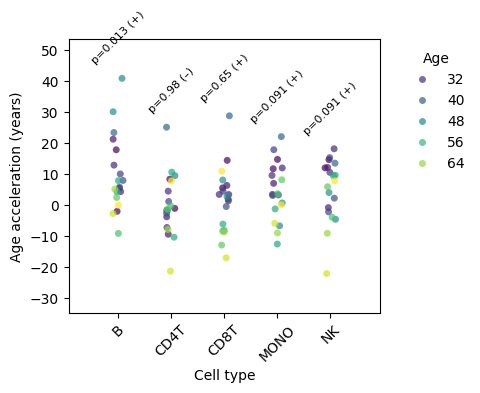

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

# Filter out NaNs
df_pivot = df_pivot[~df_pivot['diff'].isna()]

# Create figure
fig, ax = plt.subplots(figsize=(4, 4))
sns.stripplot(ax=ax, data=df_pivot, y='diff', x='cell_type', alpha=0.7, hue='age', palette='viridis')

# Axis labels
ax.set_ylabel("Age acceleration (years)")
ax.set_xlabel("Cell type")

# T-tests for each cell type
cell_types = df_pivot['cell_type'].unique()
pvals = []
means = []

for cell_type in cell_types:
    diffs = df_pivot[df_pivot['cell_type'] == cell_type]['diff']
    if len(diffs) > 1:
        stat, pval = ttest_1samp(diffs, 0)
    else:
        pval = 1.0  # Not enough data
    pvals.append(pval)
    means.append(diffs.mean())

# FDR correction
_, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

# Add annotations
for i, (mean_diff, pval_fdr) in enumerate(zip(means, pvals_fdr)):
    direction = '(+)' if mean_diff > 0 else '(–)'
    text = f"p={pval_fdr:.2g} {direction}"

    y_max = df_pivot[df_pivot['cell_type'] == cell_types[i]]['diff'].max()
    ax.text(i, y_max + 4, text, ha='center', va='bottom', rotation=45,fontsize=8)

# Adjust y-axis limits for space
ax.margins(x=.2, y=0.2)

# Final tweaks
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Age', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

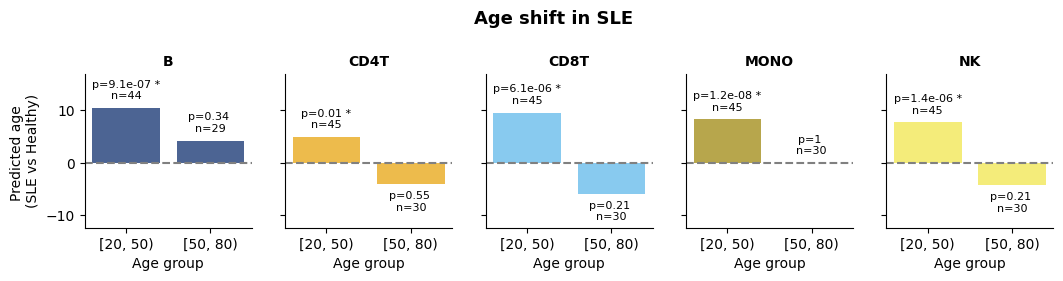

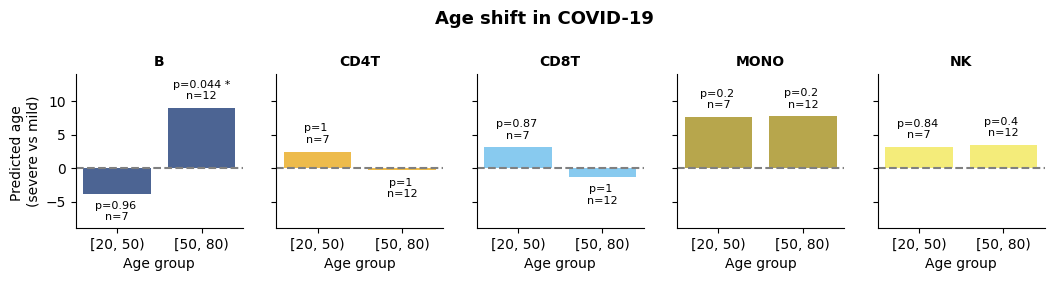

In [33]:

def wrapper_age_acceleration_aging(obs, disease_dataset):
    if disease_dataset == 'Covid_50MHH':
        disease_name = 'COVID-19'
        ctr = 'mild' #'normal'
        cond = 'severe'#'systemic lupus erythematosus'
    elif disease_dataset == 'SLE_European':
        disease_name = 'SLE' 
        ctr = 'normal' #'normal'
        cond = 'systemic lupus erythematosus'#'systemic lupus erythematosus'

    obs_disease = obs[obs['dataset'] == disease_dataset].copy()
    conds = obs_disease['condition'].unique()

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import ttest_ind
    import numpy as np

    obs_disease['age'] = obs_disease['age'].astype(float)
    obs_disease['donor_id'] = obs_disease['donor_id'].astype(str)
    conds = obs_disease['condition'].unique()

    fig, axes = plt.subplots(1, n_cell_types, figsize=(2.5*n_cell_types, 2), sharey=True)
    for i, cell_type in enumerate(cell_types):
        ax = axes[i] if len(cell_types) > 1 else axes
        # Prepare data
        obs_ct = obs_disease[obs_disease['cell_type'] == cell_type].copy()
        obs_ct = obs_ct.groupby(['donor_id', 'age', 'condition'])['predicted_age'].median().reset_index()
        if True:
            # age_bins = pd.interval_range(start=20, end=80, freq=30)  # adjust range if needed
            # obs_ct['age_bin'] = pd.cut(obs_ct['age'], bins=age_bins)
            age_bins = [20, 50, 80]
            obs_ct['age_bin'] = pd.cut(obs_ct['age'], bins=age_bins, right=False)
        else:
            # Sort by age and split donors into two roughly equal bins
            donors_sorted = obs_ct[['donor_id', 'age']].drop_duplicates().sort_values('age')
            midpoint = len(donors_sorted) // 2
            younger_donors = donors_sorted.iloc[:midpoint]['donor_id']
            older_donors = donors_sorted.iloc[midpoint:]['donor_id']

            # Assign age_bin based on donor_id
            obs_ct['age_bin'] = np.where(obs_ct['donor_id'].isin(younger_donors), 'Younger', 'Older')
            obs_ct['age_bin'] = obs_ct['age_bin'].astype(CategoricalDtype(categories=['Younger', 'Older'], ordered=True))
            age_bins = obs_ct['age_bin'].cat.categories

        # Iterate over conditions (excluding 'normal')
        if cond not in obs_ct['condition'].unique():
            raise ValueError(f"Condition '{cond}' not found in the data.")
        bar_vals = []
        bar_labels = []
        bar_pos = []

        age_bins = obs_ct['age_bin'].cat.categories
        for j, age_bin in enumerate(age_bins):
            norm_vals = obs_ct[(obs_ct['condition'] == ctr) & (obs_ct['age_bin'] == age_bin)]['predicted_age']
            # print(norm_vals)
            # aaa
            cond_vals = obs_ct[(obs_ct['condition'] == cond) & (obs_ct['age_bin'] == age_bin)]['predicted_age']

            if len(norm_vals) >= 3 and len(cond_vals) >= 3:  # minimum sample size
                tstat, pval = ttest_ind(cond_vals, norm_vals, equal_var=False)
                pval = min([pval*2, 1])
                if pval < 0.05:
                    star = '*'
                else:
                    star = ''
                diff = cond_vals.mean() - norm_vals.mean()
                label = f"p={pval:.2g} {star}\nn={len(cond_vals)}"
            else:
                diff = np.nan
                label = "n<3"

            bar_vals.append(diff)
            bar_labels.append(label)
            bar_pos.append(j)

        # Plot
        bars = ax.bar(bar_pos, bar_vals, tick_label=age_bins, color=palette_cell_types[cell_type], alpha=0.7)
        ax.axhline(0, linestyle='--', color='gray')
        ax.set_title(f"{cell_type}", weight='bold', fontsize=10)
        ax.set_xlabel("Age group")
        if i == 0:
            ax.set_ylabel(f"Predicted age \n({surrogate_names.get(cond, cond)} vs {surrogate_names.get(ctr, ctr)})")

        # Add annotations
        for bar, label in zip(bars, bar_labels):
            height = bar.get_height()
            ax.annotate(label,
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 5 if height >= 0 else -5),
                        textcoords="offset points",
                        ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(y=0.4)

        # plt.suptitle(f"{cell_type} — Predicted Age Shift vs Normal", fontsize=13)
        # plt.tight_layout()

    plt.suptitle(f"Age shift in {disease_name}", fontsize=13, y=1.2, weight='bold')
wrapper_age_acceleration_aging(obs, disease_dataset='SLE_European')
wrapper_age_acceleration_aging(obs, disease_dataset='Covid_50MHH')

### Line plot

In [34]:
import scipy.stats as stats

if False:
    for cell_type in cell_types:
        fig, axes = plt.subplots(1, len(conds), figsize=(4*len(conds), 3))
        for i, cond in enumerate(conds):
            ax = axes[i] if len(conds) > 1 else axes
            obs_d = obs_disease[(obs_disease['cell_type'] == cell_type) & (obs_disease['condition'] == cond)].copy()
            obs_d = obs_d.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()
            # - plot the goodness
            age_diff = obs_d['predicted_age'] - obs_d['age']
            
            # One-sample t-test
            t_stat, p_value = stats.ttest_1samp(age_diff, 0)
            mean_diff = age_diff.mean()
            
            # plt.title(f"{cond}\np = {p_value:.4g}, Mean age diff = {mean_diff:.2f}")

            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders)
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")

            spearman = spearmanr(obs_d['age'], obs_d['predicted_age'])[0]
            ax.set_title(f"{surrogate_names.get(cond, cond)} (Spearman:{spearman:.2f}) \n (Mean diff: {mean_diff:.2f}, p_value: {p_value:.4g})")
            # ax.get_legend().remove()
            
            i+=1
        
        # ax.legend(loc=(1.05, .2), frameon=False)
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()


## Drug perturbation

In [35]:
obs_cxcl9 = obs[obs['dataset'] == 'CXCL9'].copy() 
obs_cxcl9['condition'].unique()

array(['24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI', '24 h RPMI + metformin',
       '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib',
       '24 h rhCXCL9', '24 h rhIFN-γ', '0 h Unstimulated'], dtype=object)

In [36]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'Met.',
    # '24 h LPS + metformin + ruxolitinib': 'LPS / Met+Rux', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Met',
    # '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met+Rux',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                ('24 h LPS', '24 h LPS + metformin'),
                ('24 h LPS', '24 h LPS + ruxolitinib'),
                # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                ]
n_exp = len(experiments)

In [37]:
from statsmodels.stats.multitest import multipletests

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = [] 
slopes = []

def test_paired(df_sub):
    df_pivot = df_sub.pivot(index='donor_id', columns='condition', values='predicted_age').dropna()
    t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
    slope = (df_pivot[treatment] - df_pivot[ctr]).mean()
    return p_value, slope

def test_mixed_effect(df_sub):
    import statsmodels.formula.api as smf
    df_sub['condition'] = pd.Categorical(df_sub['condition'], categories=[ctr, treatment])
    # Fit the mixed effects model
    model = smf.mixedlm("predicted_age ~ condition", df_sub, groups=df_sub["donor_id"])
    result = model.fit()
    # # Summary of the model
    # print(result.summary())
    # Extract p-value and fixed effect estimate for treatment
    p_value = result.pvalues[f"condition[T.{treatment}]"]
    slope = result.params[f"condition[T.{treatment}]"]
    return p_value, slope
for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    for i, (ctr, treatment) in enumerate(experiments):
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        if df_sub.shape[0] < 2:
            continue  # Skip if not enough data
        
        if 'bulk' in data_type:
            p_value, slope = test_paired(df_sub)

        elif data_type == 'metacell':
            df_sub = df_sub.groupby(['donor_id', 'condition'])['predicted_age'].median().reset_index()
            p_value, slope = test_paired(df_sub)
            # p_value, slope = test_mixed_effect(df_sub)
        else:
            raise ValueError("Unsupported data type")
        raw_pvals.append(p_value)
        slopes.append(slope)
        test_labels.append((cell_type, ctr, treatment))

# Apply FDR correction
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Optionally: map corrected p-values back to plotting
pval_map = {
    (cell_type, ctr, treatment): (pval, slope)
    for (cell_type, ctr, treatment), pval, slope in zip(test_labels, corrected_pvals, slopes)
}

# Redraw plots with adjusted p-values
unique_donors = obs_cxcl9['donor_id'].unique()
donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))  # or use 'tab20', 'Set3', etc.


### All sig and not sig ones

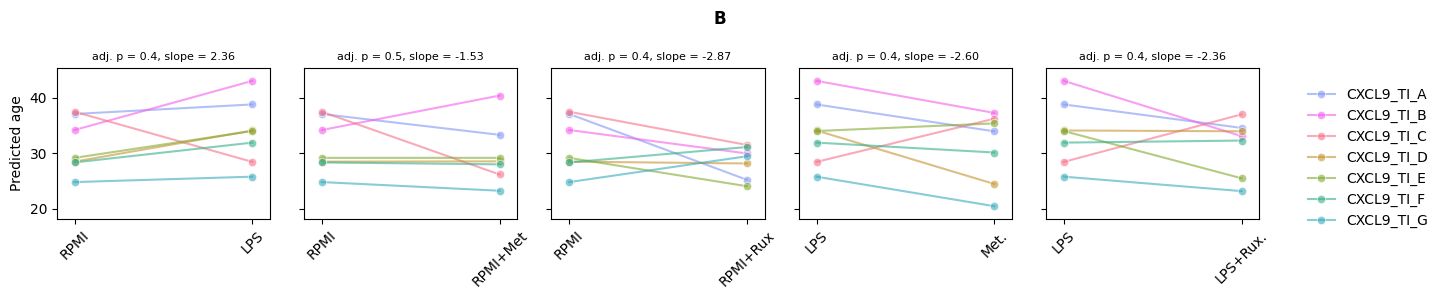

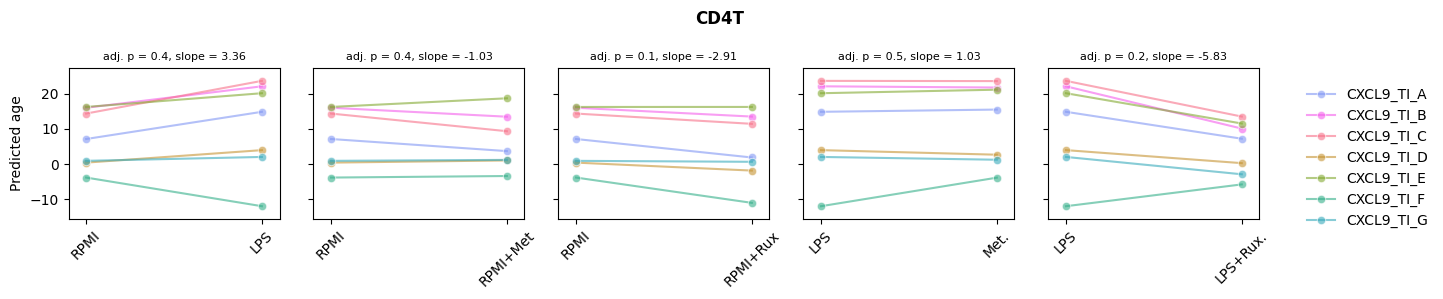

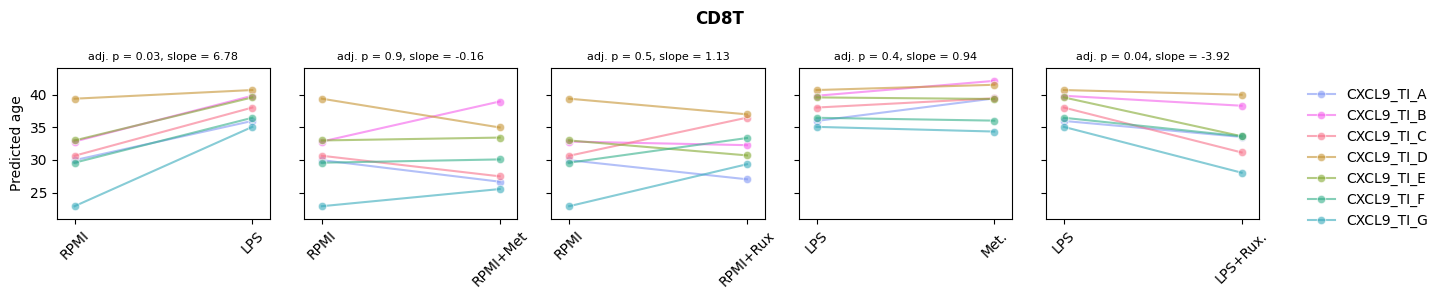

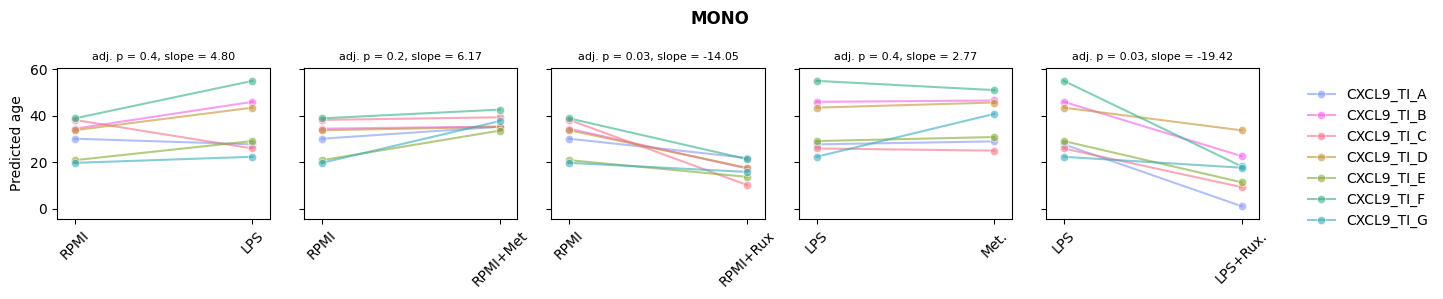

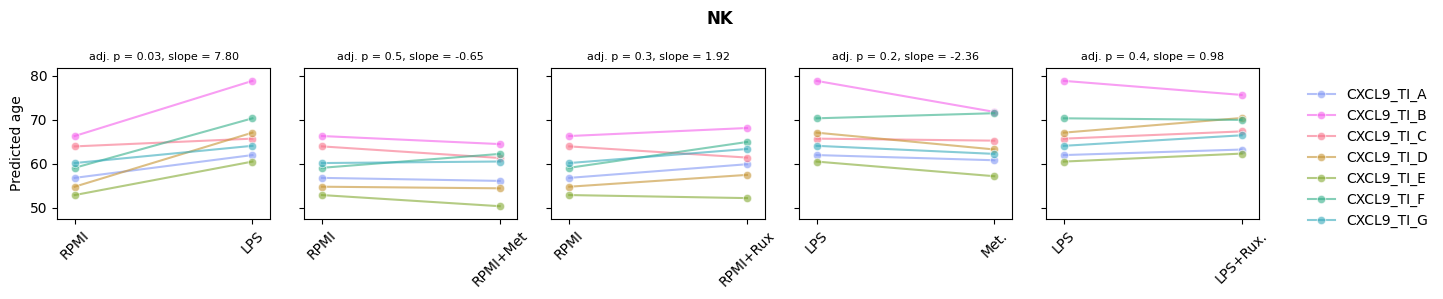

In [38]:


for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()
    fig, axes = plt.subplots(1, n_exp, figsize=(2.5*n_exp+2, 3), sharey=True)

    for i, (ctr, treatment) in enumerate(experiments):
        ax = axes[i] if n_exp > 1 else axes
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')

        available_conditions = [cond for cond in [ctr, treatment] if cond in df_pivot.columns]
        df_plot = df_pivot.reset_index().melt(id_vars='donor_id', 
                                      value_vars=available_conditions,
                                      var_name='condition', 
                                      value_name='predicted_age')
        
        df_plot['condition'] = df_plot['condition'].apply(lambda name: pretty_names.get(name, name))
        sns.lineplot(data=df_plot, x='condition', y='predicted_age', 
                     hue='donor_id', marker='o', alpha=0.6, legend=True, ax=ax, palette=donor_palette)
        
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        ax.set_title(f"adj. p = {pval:.1g}, slope = {slope:.2f}", fontsize=8)
        ax.set_ylabel("Predicted age")
        ax.set_xlabel("")
        ax.margins(x=0.1, y=0.1)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.get_legend().remove()
    ax.legend(loc=(1.2, -.1), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()

### Only sig ones

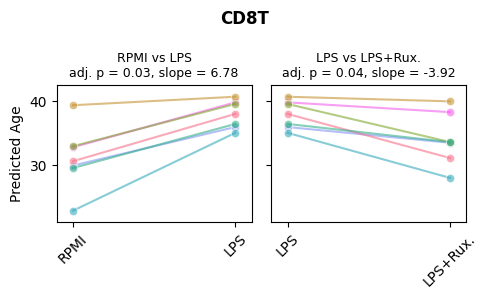

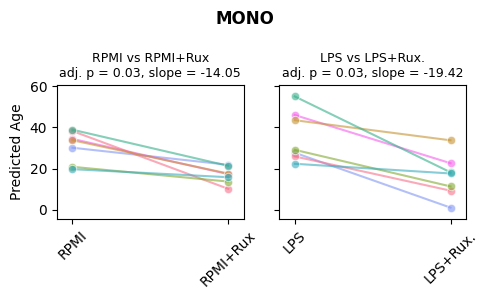

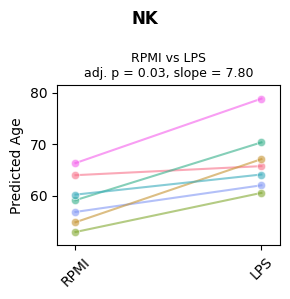

In [39]:
alpha = 0.05  # significance threshold

for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    # Get only the significant experiments for this cell type
    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < alpha
    ]
    if not significant_experiments:
        continue  # skip plotting if no significant pairs

    fig, axes = plt.subplots(1, len(significant_experiments), figsize=(2 * len(significant_experiments) + 1, 3), sharey=True)
    if len(significant_experiments) == 1:
        axes = [axes]  # make it iterable

    for i, (ctr, treatment) in enumerate(significant_experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')
        
        # Only donors with both conditions
        df_pivot = df_pivot.dropna(subset=[ctr, treatment], how='any')

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_id', 
            value_vars=[ctr, treatment], 
            var_name='condition', 
            value_name='predicted_age'
        )

        df_plot['condition'] = df_plot['condition'].map(pretty_names)
        sns.lineplot(
            data=df_plot,
            x='condition', y='predicted_age',
            hue='donor_id', marker='o', alpha=0.6,
            ax=ax, palette=donor_palette, legend=False
        )

        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        ax.set_title(f"{pretty_names.get(ctr, ctr)} vs {pretty_names.get(treatment, treatment)}\n"
                     f"adj. p = {pval:.1g}, slope = {slope:.2f}", fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("Predicted Age")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.1)

    fig.suptitle(cell_type, fontsize=12, weight='bold')
    fig.tight_layout()
    plt.show()

# TF perturbation

In [42]:
from ciim.src.insilico_perturbation.helper import experiment_perturb_tfs
# Run the experiment
tfs = 'aging_tfs' # all_tfs
ctr='Baseline'
treatment='Perturbed'
n_donors = 20

if True:
    obs_store = []
    for cell_type in cell_types:
        for dataset in datasets_all:
            obs_combined = experiment_perturb_tfs(dataset=dataset, cell_type=cell_type, data_type=data_type, n_donors=n_donors, tfs=tfs, reg_type=reg_type)
            obs_store.append(obs_combined)
    obs_all = pd.concat(obs_store, axis=0)
    obs_all.head()
else:
    pass 

Perturbing the aging TFs
Number of tfs to perturb: 7
{'Spearman': 0.6583815818183465, 'R2': 0.44911875171029214}
Perturbing the aging TFs
Number of tfs to perturb: 7
{'Spearman': 0.43039891792767204, 'R2': 0.23507138030701857}
Perturbing the aging TFs
Number of tfs to perturb: 7
{'Spearman': 0.4643591560257891, 'R2': 0.21875579236068798}
Perturbing the aging TFs
Number of tfs to perturb: 7
{'Spearman': 0.6603867691553594, 'R2': 0.16763205633148337}
Perturbing the aging TFs
Number of tfs to perturb: 7
{'Spearman': 0.483070114177562, 'R2': 0.07450896793095374}
Perturbing the aging TFs
Number of tfs to perturb: 7
{'Spearman': 0.4570658302273184, 'R2': 0.10442302317299679}
Perturbing the aging TFs
Number of tfs to perturb: 66
{'Spearman': 0.9484769380790502, 'R2': 0.4547058487696888}
Perturbing the aging TFs
Number of tfs to perturb: 66
{'Spearman': 0.931527727962339, 'R2': 0.8604364812596141}
Perturbing the aging TFs
Number of tfs to perturb: 66
{'Spearman': 0.9640986791747427, 'R2': 0.48

Text(0.5, 0, 'Cell type')

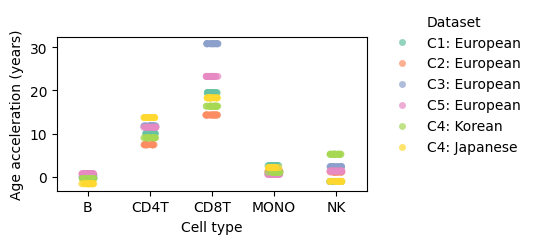

In [43]:
fig, ax = plt.subplots(figsize=(4, 2))
obs_all_c = obs_all.copy()
obs_all_c['dataset'] = obs_all_c['dataset'].apply(lambda name: surrogate_names.get(name, name))
sns.stripplot(ax=ax, data=obs_all_c, y='diff', x='cell_type', hue='dataset', 
           palette=palette_datasets_pretty, alpha=0.7)
ax.legend(loc=(1.05, .2), frameon=False, title='Dataset')
ax.set_ylabel("Age acceleration (years)")
ax.set_xlabel("Cell type")

## Test sig in perturbation

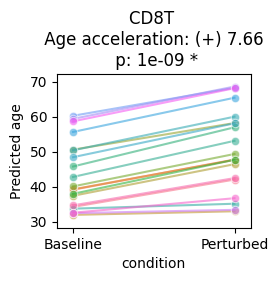

In [53]:
# format the data for test
cell_type = 'CD8T'
dataset = 'data12'
df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
p_value, slope = perform_stat_test(df_pivot, ctr=ctr, treatment=treatment)
plot_age_acceleration_donors(df_pivot, p_value, slope, ctr=ctr, treatment=treatment)
